In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print("="*50)
print("🚀 SYSTEM READY: LSTM PREDICTION MODEL")
print("="*50)
print(f"TensorFlow Version: {tf.__version__}")

🚀 SYSTEM READY: LSTM PREDICTION MODEL
TensorFlow Version: 2.18.0


In [2]:
# Konfigurasi Data
TICKER = 'NVDA'       # Ganti dengan saham pilihan Anda
START_DATE = '2018-01-01'
END_DATE = '2024-12-31'

print(f"📥 Mengunduh data {TICKER}...")
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Handling MultiIndex kolom (jika ada update yfinance terbaru)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"✅ Data berhasil diunduh. Dimensi: {df.shape}")
df.head()

📥 Mengunduh data NVDA...
✅ Data berhasil diunduh. Dimensi: (1760, 5)


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,4.928533,4.932242,4.808627,4.840272,355616000
2018-01-03,5.252900,5.283310,5.037315,5.045968,914704000
2018-01-04,5.280589,5.390854,5.258338,5.334238,583268000
2018-01-05,5.325338,5.362669,5.218534,5.295423,580124000
2018-01-08,5.488509,5.562678,5.403956,5.448952,881216000


In [ ]:
# ==========================================
# CELL 3 (UPDATE): FEATURE ENGINEERING (CALCULATION)
# ==========================================
def add_technical_indicators(df):
    df = df.copy()
    
    # 1. Basic Returns
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # 2. RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # 3. MACD Complex
    exp1 = df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal'] 
    
    # 4. Bollinger Bands
    df['BB_MA'] = df['Close'].rolling(window=20).mean()
    bb_std = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_MA'] + (bb_std * 2)
    df['BB_Lower'] = df['BB_MA'] - (bb_std * 2)
    df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])
    
    # 5. Volume & Volatility
    df['Volume_Log'] = np.log1p(df['Volume'])
    df['Volume_MA_Ratio'] = df['Volume'] / df['Volume'].rolling(window=20).mean()
    df['Volatility'] = df['Log_Return'].rolling(window=20).std()
    
    # 6. Momentum Indicators
    df['Momentum_10'] = df['Close'].pct_change(periods=10)
    df['MA_Ratio_5_20'] = df['Close'].rolling(5).mean() / df['Close'].rolling(20).mean()
    df['MA_Ratio_20_50'] = df['Close'].rolling(20).mean() / df['Close'].rolling(50).mean()
    
    # 7. ATR (Volatility)
    df['High_Low'] = df['High'] - df['Low']
    df['ATR'] = df['High_Low'].rolling(window=14).mean()
    
    # 8. Lagged Returns
    for lag in [1, 2, 3, 5]:
        df[f'Return_Lag_{lag}'] = df['Log_Return'].shift(lag)
        
    return df.dropna()

df_processed = add_technical_indicators(df)
print(f"✅ Kalkulasi Semua Indikator Selesai. Total baris data: {len(df_processed)}")

✅ Fitur Lengkap Ditambahkan. Total baris data: 1711


In [ ]:
# ==========================================
# CELL 4 (UPDATE): SELEKSI FITUR (OPTIMIZED TOP 5)
# ==========================================
# Target Prediction (Log Return Besok)
df_processed['Target'] = df_processed['Log_Return'].shift(-1)
df_processed = df_processed.dropna()

# ---------------------------------------------------------
# STRATEGI: FEATURE SELECTION
# Kita membuang fitur redundant (Noise) dan hanya menyisakan
# 5 fitur dengan Importance tertinggi dari eksperimen sebelumnya.
# ---------------------------------------------------------
feature_cols = [
    'Log_Return',    # Data Utama (Harga)
    'Volume_Log',    # Validasi Tren (Likuiditas)
    'ATR',           # Volatilitas (Range Harga) - TERPENTING
    'RSI',           # Momentum (Jenuh Beli/Jual)
    'Volatility'     # Risiko Pasar
]

# Note: 
# - MACD, Bollinger Bands, dan MA Ratios dibuang karena terbukti noise.
# - Lag Returns dibuang karena LSTM sudah memiliki memori internal.

X = df_processed[feature_cols].values
y = df_processed[['Target']].values

print(f"📌 Fitur Terpilih (Optimized - {len(feature_cols)} Fitur): {feature_cols}")
print("✅ Data Siap untuk Training Model Teroptimasi")

📌 Fitur Terpilih (16): ['Log_Return', 'RSI', 'MACD', 'MACD_Hist', 'BB_Position', 'Volume_Log', 'Volume_MA_Ratio', 'Volatility', 'Momentum_10', 'MA_Ratio_5_20', 'MA_Ratio_20_50', 'ATR', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5']


In [5]:
# Split Data (80% Train, 20% Test)
split_idx = int(len(X) * 0.8)

X_train_raw = X[:split_idx]
y_train_raw = y[:split_idx]
X_test_raw = X[split_idx:]
y_test_raw = y[split_idx:]

# Scaling (Fit hanya di Train, Transform di Test)
scaler_X = StandardScaler()
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

print("✅ Splitting & Scaling selesai (Aman dari Data Leakage)")
print(f"   Train size: {len(X_train_scaled)} | Test size: {len(X_test_scaled)}")

✅ Splitting & Scaling selesai (Aman dari Data Leakage)
   Train size: 1368 | Test size: 342


In [6]:
def create_sequences(X, y, time_steps=60):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 60

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"📦 Sequence terbentuk (Window: {TIME_STEPS} hari)")
print(f"   Input Shape: {X_train.shape} (Sampel, TimeSteps, Fitur)")

📦 Sequence terbentuk (Window: 60 hari)
   Input Shape: (1308, 60, 16) (Sampel, TimeSteps, Fitur)


In [7]:
# ==========================================
# CELL 7 (UPDATE): ARSITEKTUR BIDIRECTIONAL LSTM
# ==========================================
from tensorflow.keras.layers import Bidirectional

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    
    # Layer 1: Bidirectional LSTM (Baca pola maju & mundur)
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
    BatchNormalization(),
    Dropout(0.3),
    
    # Layer 2: LSTM Biasa
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Output Layer
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()
print("🚀 Model Upgrade: Bidirectional LSTM Siap!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,761 (366.25 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 384 (1.50 KB)

🚀 Model Upgrade: Bidirectional LSTM Siap!


In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 1.2424 - mae: 0.7652 - val_loss: 0.2968 - val_mae: 0.1187 - learning_rate: 0.0010
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.6511 - mae: 0.4911 - val_loss: 0.2990 - val_mae: 0.1325 - learning_rate: 0.0010
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.5718 - mae: 0.4329 - val_loss: 0.3029 - val_mae: 0.1469 - learning_rate: 0.0010
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.4798 - mae: 0.3663 - val_loss: 0.3002 - val_mae: 0.1577 - learning_rate: 0.0010
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.4248 - mae: 0.3230 - val_loss: 0.2864 - val_mae: 0.1369 - learning_rate: 0.0010
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.3940 - mae: 0.2931 - val_loss: 0.2812 - val_mae: 0.1385 - learning_rate: 0.0010
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.3575 - mae: 0.2590 - val_loss: 0.2772 - val_mae: 0.1425 - learning_rate: 0.0010
Epoch 

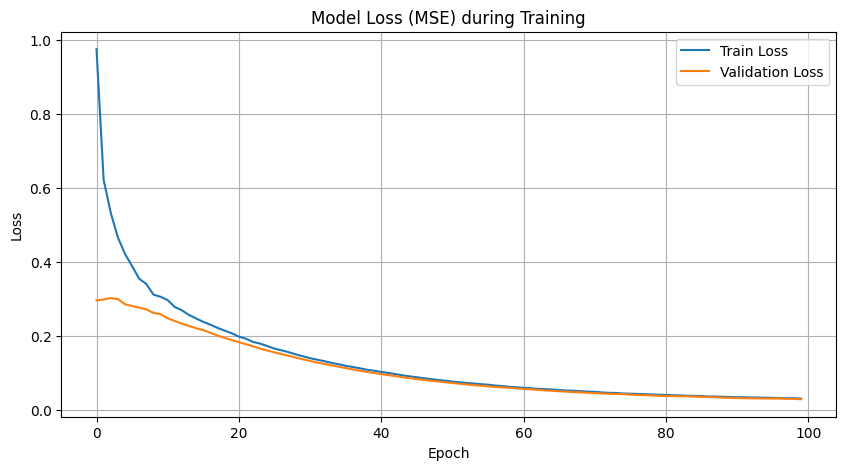

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (MSE) during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Prediksi
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse Transform (Kembalikan ke skala Log Return asli)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

# Rekonstruksi ke Harga Asli (Rupiah/Dollar)
# Kita butuh harga Close hari sebelumnya untuk menghitung: Harga_Esok = Harga_Hari_Ini * exp(Log_Return_Prediksi)
test_start_idx = split_idx + TIME_STEPS
base_prices = df_processed['Close'].iloc[test_start_idx-1 : -1].values

predicted_prices = base_prices * np.exp(y_pred.flatten())
actual_prices = df_processed['Close'].iloc[test_start_idx:].values[:len(predicted_prices)]

print("✅ Prediksi dan Rekonstruksi Harga Selesai")

✅ Prediksi dan Rekonstruksi Harga Selesai


📊 HASIL EVALUASI MODEL
1. Error Prediksi Harga (LSTM):
   • RMSE : 3.3620
   • MAE  : 2.4685
   • MAPE : 2.39%

   [Benchmark] Naive Model (Besok = Hari Ini):
   • Naive MAPE : 2.36%
   • Naive MAE  : 2.4297

⚠️ KESIMPULAN: Model LSTM performanya SETARA/DI BAWAH tebakan asal (Lagging).

2. Akurasi Arah Tren (Directional Accuracy):
   • Akurasi : 54.96%

Classification Report:
              precision    recall  f1-score   support

        Down       0.49      0.24      0.32       126
          Up       0.57      0.80      0.66       156

    accuracy                           0.55       282
   macro avg       0.53      0.52      0.49       282
weighted avg       0.53      0.55      0.51       282



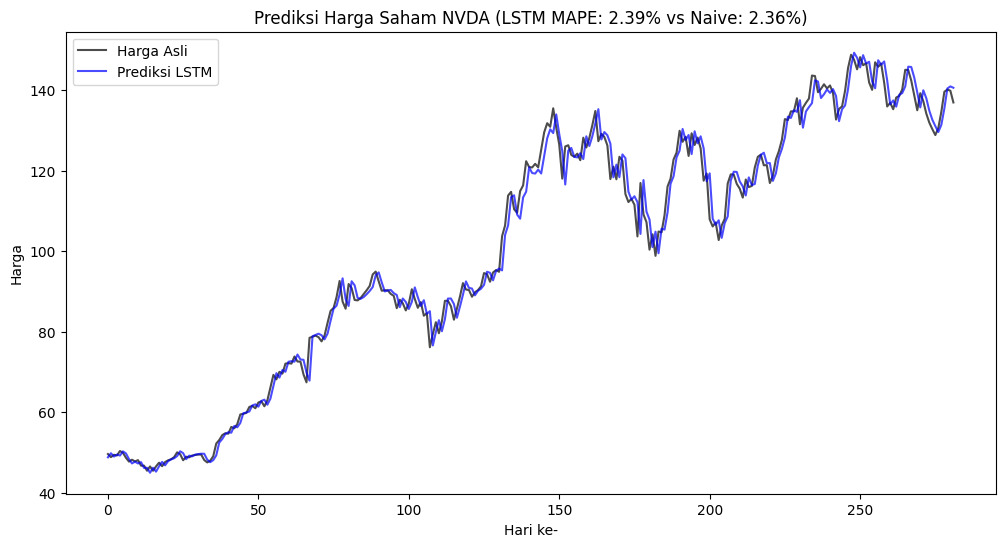

In [11]:
print("="*40)
print("📊 HASIL EVALUASI MODEL")
print("="*40)

# --- 1. Metrik Regresi (Harga) ---
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
mae = mean_absolute_error(actual_prices, predicted_prices)
mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

print(f"1. Error Prediksi Harga (LSTM):")
print(f"   • RMSE : {rmse:.4f}")
print(f"   • MAE  : {mae:.4f}")
print(f"   • MAPE : {mape:.2f}%")

# --- TAMBAHAN: Naive Baseline Check ---
# Strategi Naive: Tebak harga besok SAMA DENGAN harga hari ini
# Kita geser array: Prediksi hari ini adalah Harga Kemarin
y_naive_pred = actual_prices[:-1]
y_naive_true = actual_prices[1:]

naive_mape = np.mean(np.abs((y_naive_true - y_naive_pred) / y_naive_true)) * 100
naive_mae = mean_absolute_error(y_naive_true, y_naive_pred)

print(f"\n   [Benchmark] Naive Model (Besok = Hari Ini):")
print(f"   • Naive MAPE : {naive_mape:.2f}%")
print(f"   • Naive MAE  : {naive_mae:.4f}")

# Cek apakah LSTM lebih pintar dari Naive?
if mape < naive_mape:
    print(f"\n✅ KESIMPULAN: Model LSTM LEBIH PINTAR {(naive_mape - mape):.2f}% daripada tebakan asal.")
else:
    print(f"\n⚠️ KESIMPULAN: Model LSTM performanya SETARA/DI BAWAH tebakan asal (Lagging).")

# --- 2. Metrik Klasifikasi (Arah Pergerakan) ---
pred_direction = (y_pred.flatten() > 0).astype(int)
actual_direction = (y_actual.flatten() > 0).astype(int)
accuracy = accuracy_score(actual_direction, pred_direction)

print(f"\n2. Akurasi Arah Tren (Directional Accuracy):")
print(f"   • Akurasi : {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(actual_direction, pred_direction, target_names=['Down', 'Up']))

# Plot Hasil
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Harga Asli', color='black', alpha=0.7)
plt.plot(predicted_prices, label='Prediksi LSTM', color='blue', alpha=0.7)
plt.title(f'Prediksi Harga Saham {TICKER} (LSTM MAPE: {mape:.2f}% vs Naive: {naive_mape:.2f}%)')
plt.xlabel('Hari ke-')
plt.ylabel('Harga')
plt.legend()
plt.show()

🔍 Menganalisis Feature Importance...


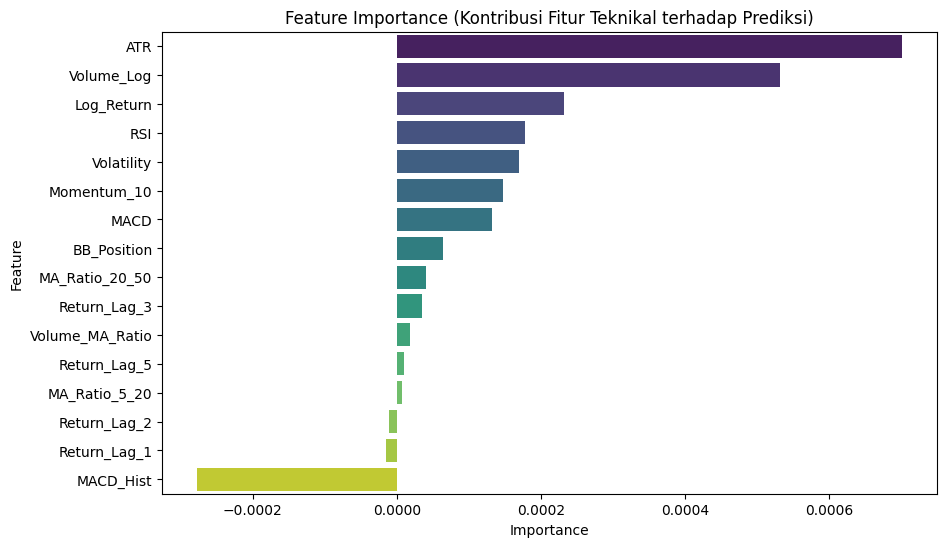


💡 INTERPRETASI UNTUK SKRIPSI:
Fitur 'ATR' adalah indikator paling dominan dalam model ini.


In [12]:
# Analisis Fitur mana yang paling berpengaruh
def get_feature_importance(model, X_test, y_test, features):
    baseline_mse = model.evaluate(X_test, y_test, verbose=0)[0]
    importances = []
    
    print("🔍 Menganalisis Feature Importance...")
    for i in range(len(features)):
        X_temp = X_test.copy()
        np.random.shuffle(X_temp[:, :, i]) # Acak kolom fitur ke-i
        mse = model.evaluate(X_temp, y_test, verbose=0)[0]
        # Semakin besar error naik, semakin penting fiturnya
        importances.append(mse - baseline_mse)
        
    return pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=False)

imp_df = get_feature_importance(model, X_test, y_test, feature_cols)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Feature Importance (Kontribusi Fitur Teknikal terhadap Prediksi)')
plt.show()

print("\n💡 INTERPRETASI UNTUK SKRIPSI:")
print(f"Fitur '{imp_df.iloc[0]['Feature']}' adalah indikator paling dominan dalam model ini.")